# Final Project: Diabetic Retinopathy Classification and Explainability

This notebook keeps the earlier baseline results as **Experiment 1** and then runs an improved
**ResNet50 transfer learning** experiment as **Experiment 2**.



## Setup



In [ ]:
# install the extra packages used for plots, Grad-CAM, and the Groq chat section
!pip -q install groq opencv-python seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.3 MB/s eta 0:00:00


## Mount Drive and Locate Dataset


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## Import Libraries

Import the main libraries used for loading data, training, evaluation, and LLM.


In [ ]:
import glob
import json
import os
import random
import warnings

import cv2
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from groq import Groq
from IPython.display import display as ipy_display
from PIL import Image as PILImage
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings("ignore")


## Set Paths and Settings

Keep the main folder names here so the rest of the notebook uses one consistent project root.


In [ ]:
# use one main project folder in Google Drive
PROJECT_ROOT = "/content/drive/MyDrive/biomedFinal"
DATA_DIR = os.path.join(PROJECT_ROOT, "dataset")
CSV_PATH = os.path.join(DATA_DIR, "train.csv")
IMAGE_DIR = os.path.join(DATA_DIR, "train_images")

# keep saved split files, processed images, and improved checkpoints in separate folders
SPLIT_DIR = os.path.join(PROJECT_ROOT, "saved_splits")
PREPROCESSED_DIR = os.path.join(PROJECT_ROOT, "preprocessed_299")
IMPROVED_CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints", "improved_resnet50_224")
IMPROVED_MODEL_PATH = os.path.join(PROJECT_ROOT, "dr_resnet50_improved_224.keras")
IMPROVED_LOG_PATH = os.path.join(IMPROVED_CHECKPOINT_DIR, "improved_training_log.csv")

# keep the main settings together near the top
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
STAGE1_EPOCHS = 15
STAGE2_EPOCHS = 15
STAGE1_LR = 1e-4
STAGE2_LR = 1e-5
UNFREEZE_TOP_LAYERS = 30
RUN_OCCLUSION_SECTION = True
OCCLUSION_PATCH_SIZE = 32
OCCLUSION_STRIDE = 32
RANDOM_SEED = 42
SAMPLE_INDEX = 30

# keep the class names in label order
CLASS_NAMES = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR",
]
NUM_CLASSES = len(CLASS_NAMES)
CLASS_NAME_MAP = {index: name for index, name in enumerate(CLASS_NAMES)}

# make the saved folders if they do not exist yet
os.makedirs(SPLIT_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DIR, exist_ok=True)
os.makedirs(IMPROVED_CHECKPOINT_DIR, exist_ok=True)

# use the same random seed each time for repeatable splits
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# keep the error messages short and simple
if not os.path.exists(PROJECT_ROOT):
    raise FileNotFoundError("project root not found")
if not os.path.exists(DATA_DIR):
    raise FileNotFoundError("dataset not found")
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError("csv not found")
if not os.path.exists(IMAGE_DIR):
    raise FileNotFoundError("images not found")

print("project root:", PROJECT_ROOT)


project root: /content/drive/MyDrive/biomedFinal


## Load Data

Read the APTOS label file and build the image paths that will be used later in the notebook.


In [ ]:
# load the csv file that has the image ids and DR labels
labels_df = pd.read_csv(CSV_PATH)

# use the normal APTOS image id column if it exists
image_id_col = "id_code" if "id_code" in labels_df.columns else labels_df.columns[0]

# the model needs the diagnosis column for training
if "diagnosis" not in labels_df.columns:
    raise ValueError("labels not found")

# turn each image id into a full file path
labels_df[image_id_col] = labels_df[image_id_col].astype(str)
labels_df["filepath"] = labels_df[image_id_col].apply(
    lambda image_id: os.path.join(IMAGE_DIR, f"{image_id}.png")
)

# drop any rows whose image file is missing
labels_df = labels_df[labels_df["filepath"].apply(os.path.exists)].copy()

# add readable label names for plots and reports
labels_df["label_name"] = labels_df["diagnosis"].map(CLASS_NAME_MAP)
labels_df = labels_df.sort_values("diagnosis").reset_index(drop=True)

print("images:", len(labels_df))
print(labels_df["label_name"].value_counts().sort_index())

labels_df.head()


images: 3662
label_name
Mild                 370
Moderate             999
No DR               1805
Proliferative DR     295
Severe               193
Name: count, dtype: int64


,id_code,diagnosis,filepath,label_name
0,fe0e2dee1834,0,/content/drive/MyDrive/biomedFinal/dataset/tra...,No DR
1,fe3b0e50be78,0,/content/drive/MyDrive/biomedFinal/dataset/tra...,No DR
2,fe3f62695b2d,0,/content/drive/MyDrive/biomedFinal/dataset/tra...,No DR
3,80b5697f2a5e,0,/content/drive/MyDrive/biomedFinal/dataset/tra...,No DR
4,80c67efc8101,0,/content/drive/MyDrive/biomedFinal/dataset/tra...,No DR


## Experiment 1: Baseline Summary

Keep the earlier baseline results here as a reference point before running the improved experiment.


In [ ]:
# keep the earlier baseline numbers from the previous notebook
baseline_reference_metrics = {
    "accuracy": 0.5055,
    "weighted_f1": 0.4699,
    "weighted_auc_ovr": 0.8411,
    "moderate_recall": 0.01,
    "proliferative_recall": 0.00,
    "class_highlights": {
        "No DR": {"precision": 0.90, "recall": 0.82, "f1_score": 0.86},
        "Moderate": {"precision": 0.50, "recall": 0.01, "f1_score": 0.03},
        "Proliferative DR": {"precision": 0.00, "recall": 0.00, "f1_score": 0.00},
    },
}

# show the main baseline scores in one small table
baseline_metric_df = pd.DataFrame(
    {
        "accuracy": [baseline_reference_metrics["accuracy"]],
        "weighted_f1": [baseline_reference_metrics["weighted_f1"]],
        "weighted_auc_ovr": [baseline_reference_metrics["weighted_auc_ovr"]],
        "moderate_recall": [baseline_reference_metrics["moderate_recall"]],
        "proliferative_recall": [baseline_reference_metrics["proliferative_recall"]],
    },
    index=["baseline"],
)

# show the weakest and strongest class behavior from the baseline
baseline_class_df = pd.DataFrame(baseline_reference_metrics["class_highlights"]).T

display(baseline_metric_df)
display(baseline_class_df)


,accuracy,weighted_f1,weighted_auc_ovr,moderate_recall,proliferative_recall
baseline,0.5055,0.4699,0.8411,0.01,0.0


,precision,recall,f1_score
No DR,0.9,0.82,0.86
Moderate,0.5,0.01,0.03
Proliferative DR,0.0,0.00,0.00


## Save Fixed Splits

Save one train/validation/test split to Drive so the improved run can reuse the same rows later.


In [ ]:
# keep one saved split file for each subset
train_split_path = os.path.join(SPLIT_DIR, "train_split.csv")
val_split_path = os.path.join(SPLIT_DIR, "val_split.csv")
test_split_path = os.path.join(SPLIT_DIR, "test_split.csv")

# reuse the same split files if they already exist
if os.path.exists(train_split_path) and os.path.exists(val_split_path) and os.path.exists(test_split_path):
    train_df = pd.read_csv(train_split_path)
    val_df = pd.read_csv(val_split_path)
    test_df = pd.read_csv(test_split_path)
    print("saved splits loaded")
else:
    # first split off 30 percent for validation and test
    train_df, temp_df = train_test_split(
        labels_df,
        test_size=0.30,
        stratify=labels_df["diagnosis"],
        random_state=RANDOM_SEED,
    )

    # then split that 30 percent in half for validation and test
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        stratify=temp_df["diagnosis"],
        random_state=RANDOM_SEED,
    )

    # save the fixed split files so later reruns use the same rows
    train_df.to_csv(train_split_path, index=False)
    val_df.to_csv(val_split_path, index=False)
    test_df.to_csv(test_split_path, index=False)
    print("saved splits created")

# reset the row numbers after loading or creating the split files
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("train:", len(train_df))
print("val:", len(val_df))
print("test:", len(test_df))


saved splits loaded
train: 2563
val: 549
test: 550


## Preprocess Images for Improved Run

Cache cropped and resized fundus images in a new folder so the improved experiment can reuse them.


In [ ]:
# build a processed file path for each image id
def get_processed_path(image_id):
    return os.path.join(PREPROCESSED_DIR, f"{str(image_id)}.png")

# remove large black borders so the retina uses more of the image
def crop_fundus_image(rgb_image, threshold=10):
    gray_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)
    mask = gray_image > threshold

    if not np.any(mask):
        return rgb_image

    y_coords, x_coords = np.where(mask)
    y1, y2 = y_coords.min(), y_coords.max() + 1
    x1, x2 = x_coords.min(), x_coords.max() + 1

    return rgb_image[y1:y2, x1:x2]

# crop, resize, and save one processed image
def preprocess_and_save_image(input_path, output_path, target_size):
    image = PILImage.open(input_path).convert("RGB")
    image = np.array(image)
    image = crop_fundus_image(image)
    image = cv2.resize(image, (target_size[1], target_size[0]))
    PILImage.fromarray(image).save(output_path)

# gather all unique rows across the three saved splits
all_split_rows = pd.concat([train_df, val_df, test_df], axis=0)
all_split_rows = all_split_rows.drop_duplicates(subset=[image_id_col]).reset_index(drop=True)

# only build files that are not already cached
created_count = 0
for row_index, row in all_split_rows.iterrows():
    output_path = get_processed_path(row[image_id_col])

    if not os.path.exists(output_path):
        preprocess_and_save_image(row["filepath"], output_path, IMG_SIZE)
        created_count += 1

    if (row_index + 1) % 500 == 0:
        print("done:", row_index + 1)

# add the processed image path to each split dataframe
for split_df in [train_df, val_df, test_df]:
    split_df["processed_path"] = split_df[image_id_col].apply(get_processed_path)

print("new files:", created_count)


done: 500
done: 1000
done: 1500
done: 2000
done: 2500
done: 3000
done: 3500
new files: 0


## Data Generators for Improved Run

Use conservative augmentation for training, and keep validation and test images unaugmented.


In [ ]:
# use the ResNet50 preprocessing function instead of simple rescale
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.10,
    brightness_range=(0.9, 1.1),
)

# do not augment validation or test images
eval_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

# training generator uses shuffle so the model sees mixed batches
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="processed_path",
    y_col="label_name",
    classes=CLASS_NAMES,
    target_size=IMG_SIZE,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=RANDOM_SEED,
)

# validation generator stays in a fixed order
val_gen = eval_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="processed_path",
    y_col="label_name",
    classes=CLASS_NAMES,
    target_size=IMG_SIZE,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# test generator also stays in a fixed order for evaluation
test_gen = eval_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="processed_path",
    y_col="label_name",
    classes=CLASS_NAMES,
    target_size=IMG_SIZE,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False,
)


Found 2563 validated image filenames belonging to 5 classes.
Found 549 validated image filenames belonging to 5 classes.
Found 550 validated image filenames belonging to 5 classes.


## Build Improved ResNet50 Model

Build the improved transfer learning model that will be trained in two stages.


In [ ]:
# find the nested cnn backbone inside the full classifier
def get_base_cnn(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            return layer
    raise ValueError("backbone not found")

# build the main ResNet50 model with a small custom head
def build_improved_model():
    base_model = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs, name="dr_resnet50_improved")

# unfreeze only the top part of the backbone for stage 2
def set_fine_tune_layers(model, unfreeze_top_layers):
    base_cnn = get_base_cnn(model)
    base_cnn.trainable = True

    for layer in base_cnn.layers[:-unfreeze_top_layers]:
        layer.trainable = False

    for layer in base_cnn.layers[-unfreeze_top_layers:]:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

    return model

# start with the frozen stage 1 model
model = build_improved_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "dr_resnet50_improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Train Improved Model

First train the new head with the backbone frozen, then fine-tune the top part of ResNet50.


In [ ]:
# class weights help the smaller classes count more during training
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_df["diagnosis"].values,
)
class_weights = {index: float(weight) for index, weight in enumerate(class_weights_array)}

# keep stage 1 and stage 2 files separate from the earlier baseline notebook
STAGE1_BEST_PATH = os.path.join(IMPROVED_CHECKPOINT_DIR, "stage1_best.keras")
STAGE1_LATEST_PATH = os.path.join(IMPROVED_CHECKPOINT_DIR, "stage1_latest.keras")
STAGE2_BEST_PATH = os.path.join(IMPROVED_CHECKPOINT_DIR, "stage2_best.keras")
STAGE2_LATEST_PATH = os.path.join(IMPROVED_CHECKPOINT_DIR, "stage2_latest.keras")
TRAINING_STATE_PATH = os.path.join(IMPROVED_CHECKPOINT_DIR, "improved_training_state.json")

# use a tiny state file so Colab can resume after runtime resets
def read_training_state():
    default_state = {
        "stage1_last_epoch": 0,
        "stage1_completed": False,
        "stage2_last_epoch": 0,
        "stage2_completed": False,
    }

    if not os.path.exists(TRAINING_STATE_PATH):
        return default_state

    with open(TRAINING_STATE_PATH, "r") as file:
        saved_state = json.load(file)

    default_state.update(saved_state)
    return default_state

# save the latest finished epoch after each epoch
def write_training_state(state):
    with open(TRAINING_STATE_PATH, "w") as file:
        json.dump(state, file, indent=2)

# keep one extra callback that saves the latest model and epoch
def make_state_callback(stage_name, latest_model_path):
    def on_epoch_end(epoch, logs=None):
        model.save(latest_model_path)
        state = read_training_state()
        state[f"{stage_name}_last_epoch"] = int(epoch + 1)
        write_training_state(state)

    return tf.keras.callbacks.LambdaCallback(on_epoch_end=on_epoch_end)


In [ ]:
# load the last saved state for the improved experiment
training_state = read_training_state()

# stage 1 trains the new head while the backbone stays frozen
if not training_state["stage1_completed"]:
    if os.path.exists(STAGE1_LATEST_PATH) and training_state["stage1_last_epoch"] > 0:
        model = tf.keras.models.load_model(STAGE1_LATEST_PATH)
        print(f"resume stage 1 from epoch {training_state['stage1_last_epoch'] + 1}")
    else:
        model = build_improved_model()
        print("start stage 1")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=STAGE1_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    stage1_callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            STAGE1_BEST_PATH,
            monitor="val_loss",
            save_best_only=True,
        ),
        tf.keras.callbacks.CSVLogger(IMPROVED_LOG_PATH, append=True),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
        ),
        make_state_callback("stage1", STAGE1_LATEST_PATH),
    ]

    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=STAGE1_EPOCHS,
        initial_epoch=training_state["stage1_last_epoch"],
        class_weight=class_weights,
        callbacks=stage1_callbacks,
    )

    if os.path.exists(STAGE1_BEST_PATH):
        model = tf.keras.models.load_model(STAGE1_BEST_PATH)

    training_state = read_training_state()
    training_state["stage1_completed"] = True
    write_training_state(training_state)
else:
    print("stage 1 already done")

# reload the state before starting stage 2
training_state = read_training_state()

# stage 2 fine-tunes only the top part of the backbone
if not training_state["stage2_completed"]:
    if os.path.exists(STAGE2_LATEST_PATH) and training_state["stage2_last_epoch"] > 0:
        model = tf.keras.models.load_model(STAGE2_LATEST_PATH)
        print(f"resume stage 2 from epoch {training_state['stage2_last_epoch'] + 1}")
    elif os.path.exists(STAGE1_BEST_PATH):
        model = tf.keras.models.load_model(STAGE1_BEST_PATH)
        print("start stage 2")
    elif os.path.exists(STAGE1_LATEST_PATH):
        model = tf.keras.models.load_model(STAGE1_LATEST_PATH)
        print("start stage 2")
    else:
        raise FileNotFoundError("stage 1 model not found")

    model = set_fine_tune_layers(model, UNFREEZE_TOP_LAYERS)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=STAGE2_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    stage2_callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            STAGE2_BEST_PATH,
            monitor="val_loss",
            save_best_only=True,
        ),
        tf.keras.callbacks.CSVLogger(IMPROVED_LOG_PATH, append=True),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
        ),
        make_state_callback("stage2", STAGE2_LATEST_PATH),
    ]

    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=STAGE2_EPOCHS,
        initial_epoch=training_state["stage2_last_epoch"],
        class_weight=class_weights,
        callbacks=stage2_callbacks,
    )

    if os.path.exists(STAGE2_BEST_PATH):
        model = tf.keras.models.load_model(STAGE2_BEST_PATH)

    training_state = read_training_state()
    training_state["stage2_completed"] = True
    write_training_state(training_state)
else:
    print("stage 2 already done")

# save the best finished improved model for evaluation and explainability
if os.path.exists(STAGE2_BEST_PATH):
    model = tf.keras.models.load_model(STAGE2_BEST_PATH)
elif os.path.exists(STAGE2_LATEST_PATH):
    model = tf.keras.models.load_model(STAGE2_LATEST_PATH)
elif os.path.exists(STAGE1_BEST_PATH):
    model = tf.keras.models.load_model(STAGE1_BEST_PATH)

model.save(IMPROVED_MODEL_PATH)
print("improved model saved")


stage 1 already done
stage 2 already done
improved model saved


## Evaluate Improved Model

Evaluate the improved model on the held-out test split only.


In [ ]:
# load the best improved model before test evaluation
if os.path.exists(STAGE2_BEST_PATH):
    model = tf.keras.models.load_model(STAGE2_BEST_PATH)
elif os.path.exists(IMPROVED_MODEL_PATH):
    model = tf.keras.models.load_model(IMPROVED_MODEL_PATH)
else:
    raise FileNotFoundError("improved model not found")

# reset the generator so predictions line up with the test dataframe order
test_gen.reset()
test_probs = model.predict(test_gen, verbose=1)
test_preds = np.argmax(test_probs, axis=1)
y_true = test_gen.classes
y_true_one_hot = label_binarize(y_true, classes=np.arange(NUM_CLASSES))

# calculate the main metrics for the improved experiment
improved_accuracy = accuracy_score(y_true, test_preds)
improved_weighted_f1 = f1_score(y_true, test_preds, average="weighted")
improved_weighted_auc = roc_auc_score(
    y_true_one_hot,
    test_probs,
    multi_class="ovr",
    average="weighted",
)

# keep the full class report for later comparison
improved_report_text = classification_report(
    y_true,
    test_preds,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
)
improved_report_dict = classification_report(
    y_true,
    test_preds,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
    output_dict=True,
)

# store the main improved metrics in one small dictionary
improved_metrics = {
    "accuracy": float(improved_accuracy),
    "weighted_f1": float(improved_weighted_f1),
    "weighted_auc_ovr": float(improved_weighted_auc),
}

# keep one evaluation dataframe so later XAI sections can reuse it
evaluation_results_df = test_df.copy().reset_index(drop=True)
evaluation_results_df["true_index"] = y_true
evaluation_results_df["pred_index"] = test_preds
evaluation_results_df["true_label"] = [CLASS_NAMES[index] for index in y_true]
evaluation_results_df["pred_label"] = [CLASS_NAMES[index] for index in test_preds]
evaluation_results_df["confidence"] = test_probs.max(axis=1)
evaluation_results_df["is_correct"] = evaluation_results_df["true_index"] == evaluation_results_df["pred_index"]

print("test accuracy:", round(improved_metrics["accuracy"], 4))
print("weighted f1:", round(improved_metrics["weighted_f1"], 4))
print("weighted auc ovr:", round(improved_metrics["weighted_auc_ovr"], 4))
print()
print(improved_report_text)


35/35 ━━━━━━━━━━━━━━━━━━━━ 230s 6s/step
test accuracy: 0.7873
weighted f1: 0.782
weighted auc ovr: 0.9486

                  precision    recall  f1-score   support

           No DR     0.9296    0.9742    0.9514       271
            Mild     0.5000    0.6964    0.5821        56
        Moderate     0.7391    0.6800    0.7083       150
          Severe     0.4091    0.3103    0.3529        29
Proliferative DR     0.6786    0.4318    0.5278        44

        accuracy                         0.7873       550
       macro avg     0.6513    0.6186    0.6245       550
    weighted avg     0.7864    0.7873    0.7820       550



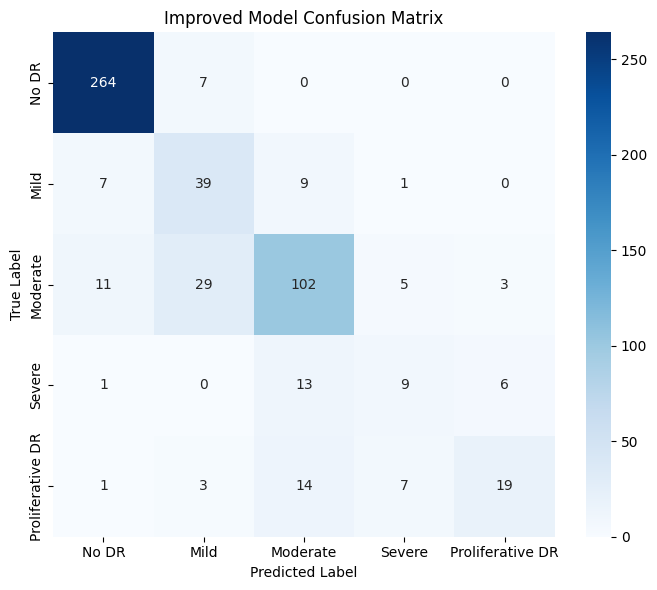

In [ ]:
# show the confusion matrix for the improved test predictions
test_cm = confusion_matrix(y_true, test_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title("Improved Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


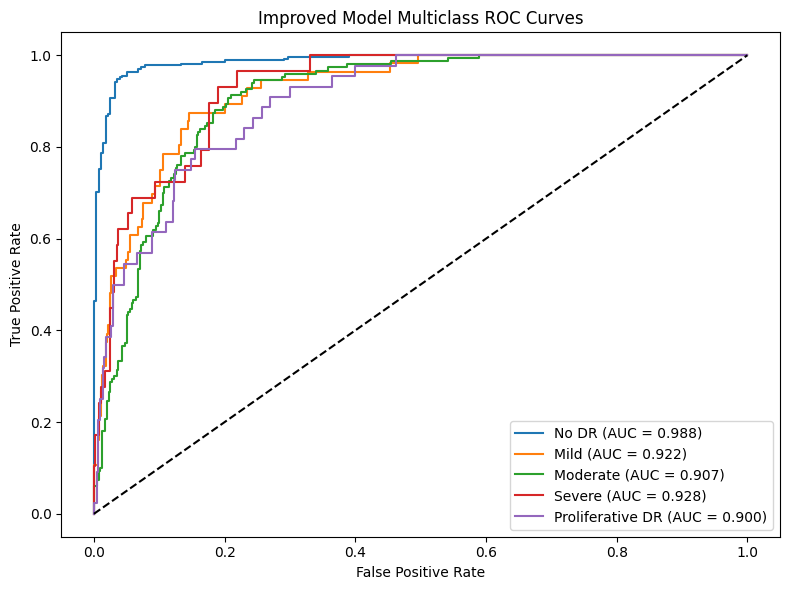

In [ ]:
# plot one ROC curve for each class using the improved model probabilities
plt.figure(figsize=(8, 6))

for class_index, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_one_hot[:, class_index], test_probs[:, class_index])
    roc_auc_value = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc_value:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.title("Improved Model Multiclass ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


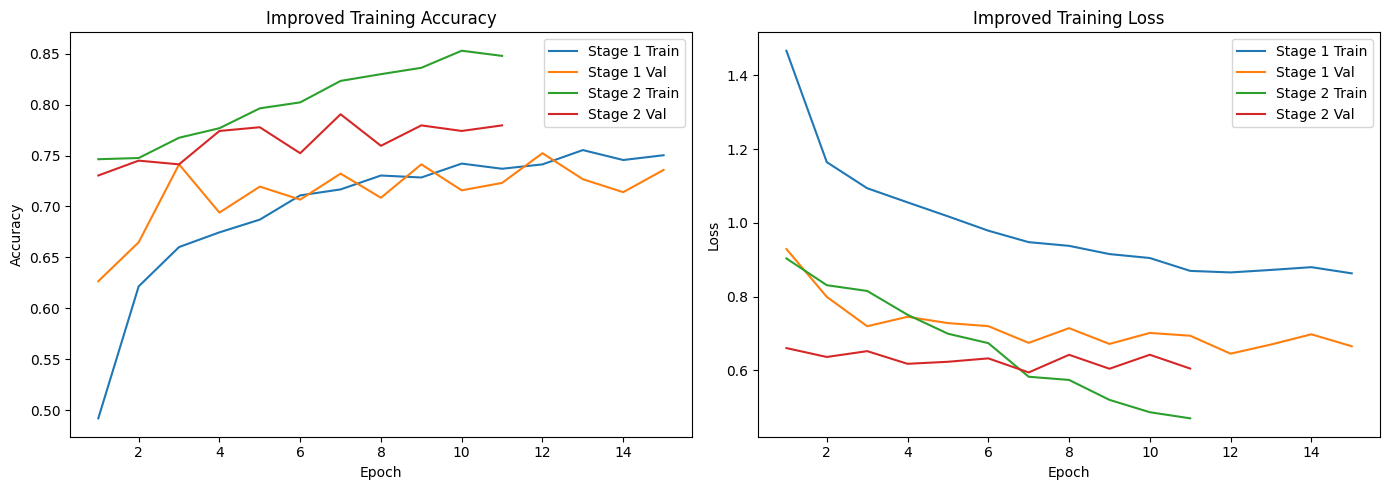

In [ ]:
# use the csv log to plot stage 1 and stage 2 training curves
if os.path.exists(IMPROVED_LOG_PATH):
    log_df = pd.read_csv(IMPROVED_LOG_PATH)

    # stage 2 starts when the epoch numbers reset
    reset_points = log_df.index[log_df["epoch"].diff().fillna(0) < 0].tolist()

    if reset_points:
        split_index = reset_points[0]
        stage1_log = log_df.iloc[:split_index].copy()
        stage2_log = log_df.iloc[split_index:].copy()
    else:
        stage1_log = log_df.copy()
        stage2_log = pd.DataFrame()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # plot accuracy for both stages
    if not stage1_log.empty:
        axes[0].plot(stage1_log["epoch"] + 1, stage1_log["accuracy"], label="Stage 1 Train")
        axes[0].plot(stage1_log["epoch"] + 1, stage1_log["val_accuracy"], label="Stage 1 Val")
    if not stage2_log.empty:
        axes[0].plot(stage2_log["epoch"] + 1, stage2_log["accuracy"], label="Stage 2 Train")
        axes[0].plot(stage2_log["epoch"] + 1, stage2_log["val_accuracy"], label="Stage 2 Val")
    axes[0].set_title("Improved Training Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    # plot loss for both stages
    if not stage1_log.empty:
        axes[1].plot(stage1_log["epoch"] + 1, stage1_log["loss"], label="Stage 1 Train")
        axes[1].plot(stage1_log["epoch"] + 1, stage1_log["val_loss"], label="Stage 1 Val")
    if not stage2_log.empty:
        axes[1].plot(stage2_log["epoch"] + 1, stage2_log["loss"], label="Stage 2 Train")
        axes[1].plot(stage2_log["epoch"] + 1, stage2_log["val_loss"], label="Stage 2 Val")
    axes[1].set_title("Improved Training Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("log not found")


## Compare Baseline and Improved Results

Compare the earlier baseline run against the new improved experiment on the same 5-class task.


In [ ]:
# pull the key class recalls from the improved report
improved_moderate_recall = float(improved_report_dict["Moderate"]["recall"])
improved_proliferative_recall = float(improved_report_dict["Proliferative DR"]["recall"])

# put the baseline and improved scores side by side
comparison_df = pd.DataFrame(
    {
        "baseline": [
            baseline_reference_metrics["accuracy"],
            baseline_reference_metrics["weighted_f1"],
            baseline_reference_metrics["weighted_auc_ovr"],
            baseline_reference_metrics["moderate_recall"],
            baseline_reference_metrics["proliferative_recall"],
        ],
        "improved": [
            improved_metrics["accuracy"],
            improved_metrics["weighted_f1"],
            improved_metrics["weighted_auc_ovr"],
            improved_moderate_recall,
            improved_proliferative_recall,
        ],
    },
    index=[
        "accuracy",
        "weighted_f1",
        "weighted_auc_ovr",
        "moderate_recall",
        "proliferative_recall",
    ],
)

# check the main success conditions from the plan
beats_accuracy = improved_metrics["accuracy"] > baseline_reference_metrics["accuracy"]
beats_weighted_f1 = improved_metrics["weighted_f1"] > baseline_reference_metrics["weighted_f1"]
beats_moderate_recall = improved_moderate_recall > baseline_reference_metrics["moderate_recall"]
beats_proliferative_recall = improved_proliferative_recall > baseline_reference_metrics["proliferative_recall"]

display(comparison_df)

print("better accuracy:", beats_accuracy)
print("better weighted f1:", beats_weighted_f1)
print("better moderate recall:", beats_moderate_recall)
print("better proliferative recall:", beats_proliferative_recall)


,baseline,improved
accuracy,0.5055,0.787273
weighted_f1,0.4699,0.782038
weighted_auc_ovr,0.8411,0.948632
moderate_recall,0.0100,0.680000
proliferative_recall,0.0000,0.431818


better accuracy: True
better weighted f1: True
better moderate recall: True
better proliferative recall: True


## Grad-CAM

Use the improved model to show which part of one test image had the biggest effect on the prediction.


sample image: c7e827fc7f41.png
true class: Moderate
predicted class: Moderate
confidence: 0.3673
grad-cam focus area: lower center retina


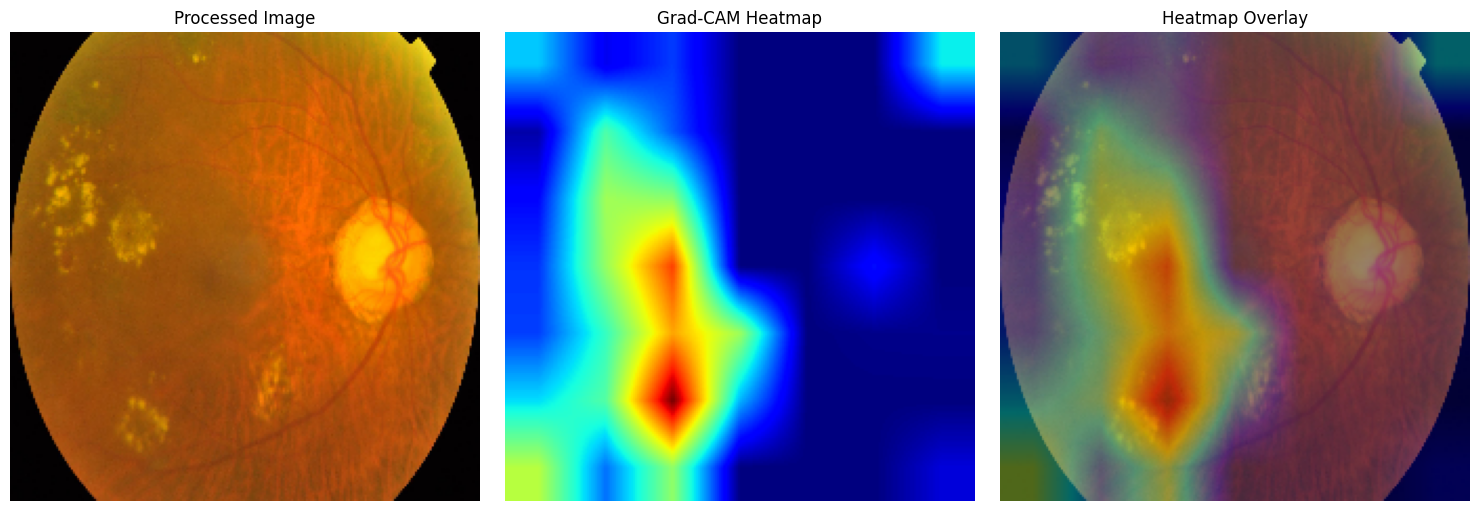

In [ ]:
# load one processed image so the heatmap lines up with the model input
def load_image_for_model(image_path, target_size):
    pil_img = PILImage.open(image_path).convert("RGB")
    resized_img = pil_img.resize((target_size[1], target_size[0]))
    raw_array = np.array(resized_img).astype("float32")
    model_array = tf.keras.applications.resnet50.preprocess_input(raw_array.copy())
    return resized_img, raw_array, model_array

# build the Grad-CAM heatmap directly from the backbone outputs
def make_gradcam_heatmap(model_array, model):
    base_cnn = get_base_cnn(model)
    img_tensor = tf.cast(np.expand_dims(model_array, axis=0), tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs = base_cnn(img_tensor, training=False)
        tape.watch(conv_outputs)

        # pass the backbone features through the custom head
        x = conv_outputs
        found_base = False
        for layer in model.layers:
            if isinstance(layer, tf.keras.layers.InputLayer):
                continue
            if layer is base_cnn:
                found_base = True
                continue
            if found_base:
                x = layer(x, training=False)
        predictions = x

        pred_index = tf.argmax(predictions[0])
        target_class_channel = predictions[:, pred_index]

    grads = tape.gradient(target_class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs_np = conv_outputs[0].numpy()

    heatmap = np.sum(conv_outputs_np * pooled_grads.numpy(), axis=-1)
    heatmap = np.maximum(heatmap, 0)

    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    pred_index = int(pred_index.numpy())
    confidence = float(predictions[0][pred_index].numpy())
    return heatmap, pred_index, confidence

# overlay the heatmap on top of the image
def overlay_heatmap_on_image(display_img, heatmap, alpha=0.40):
    image = np.array(display_img)
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap)
    colored_heatmap = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    colored_heatmap = cv2.cvtColor(colored_heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(image, 1 - alpha, colored_heatmap, alpha, 0)
    return heatmap, overlay

# turn the hottest area into a simple text description
def describe_attention_region(heatmap):
    max_y, max_x = np.unravel_index(np.argmax(heatmap), heatmap.shape)
    height, width = heatmap.shape

    vertical = "upper" if max_y < height / 3 else "central" if max_y < 2 * height / 3 else "lower"
    horizontal = "left" if max_x < width / 3 else "center" if max_x < 2 * width / 3 else "right"

    return f"{vertical} {horizontal} retina"

# try to use a correct non-zero DR example so the explanation is easier to inspect
candidate_rows = evaluation_results_df[
    (evaluation_results_df["is_correct"]) & (evaluation_results_df["true_index"] > 0)
].reset_index(drop=True)

if len(candidate_rows) > 0:
    sample_row = candidate_rows.iloc[min(SAMPLE_INDEX, len(candidate_rows) - 1)]
else:
    sample_row = evaluation_results_df.iloc[min(SAMPLE_INDEX, len(evaluation_results_df) - 1)]

sample_path = sample_row["processed_path"]
sample_display_img, sample_raw_array, sample_model_array = load_image_for_model(sample_path, IMG_SIZE)
gradcam_heatmap, predicted_class_index, predicted_confidence = make_gradcam_heatmap(sample_model_array, model)
gradcam_heatmap_resized, gradcam_overlay = overlay_heatmap_on_image(sample_display_img, gradcam_heatmap)

true_class_name = sample_row["true_label"]
predicted_class_name = CLASS_NAMES[predicted_class_index]
gradcam_region_text = describe_attention_region(gradcam_heatmap_resized)

print("sample image:", os.path.basename(sample_path))
print("true class:", true_class_name)
print("predicted class:", predicted_class_name)
print(f"confidence: {predicted_confidence:.4f}")
print("grad-cam focus area:", gradcam_region_text)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample_display_img)
axes[0].set_title("Processed Image")
axes[0].axis("off")

axes[1].imshow(gradcam_heatmap_resized, cmap="jet")
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis("off")

axes[2].imshow(gradcam_overlay)
axes[2].set_title("Heatmap Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## Occlusion Sensitivity

Cover small patches of the sample image to see where the confidence drops the most.


largest drop: upper center retina, max drop: 0.3065


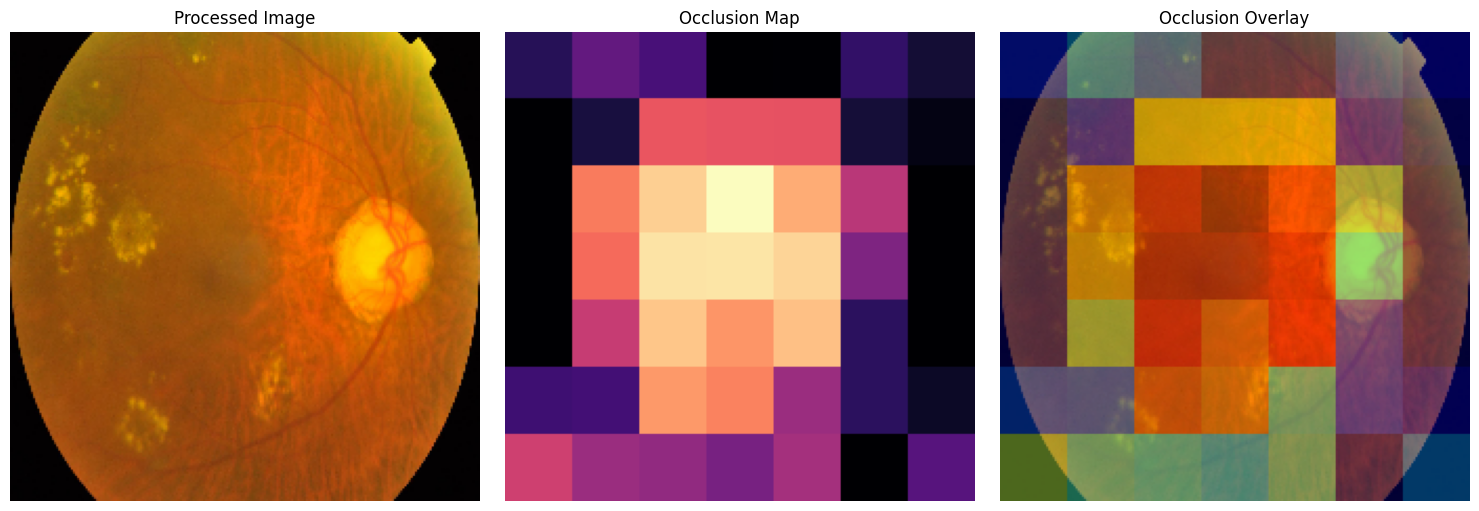

In [ ]:
# build the list of patch positions across the image
def build_occlusion_positions(length, patch_size, stride):
    positions = list(range(0, max(length - patch_size + 1, 1), stride))
    last_position = length - patch_size

    if positions and last_position > 0 and positions[-1] != last_position:
        positions.append(last_position)
    elif not positions:
        positions = [0]

    return positions

# cover one patch at a time and measure the confidence drop
def run_occlusion_sensitivity(raw_array, model, patch_size=32, stride=32):
    model_input = tf.keras.applications.resnet50.preprocess_input(raw_array.copy())
    base_probs = model.predict(np.expand_dims(model_input, axis=0), verbose=0)[0]
    pred_index = int(np.argmax(base_probs))
    base_confidence = float(base_probs[pred_index])

    height, width, _ = raw_array.shape
    raw_map = np.zeros((height, width), dtype="float32")
    count_map = np.zeros((height, width), dtype="float32")

    y_positions = build_occlusion_positions(height, patch_size, stride)
    x_positions = build_occlusion_positions(width, patch_size, stride)

    for y in y_positions:
        for x in x_positions:
            occluded_img = raw_array.copy()
            occluded_img[y:y + patch_size, x:x + patch_size, :] = 0.0
            occluded_input = tf.keras.applications.resnet50.preprocess_input(occluded_img.copy())

            occluded_probs = model.predict(np.expand_dims(occluded_input, axis=0), verbose=0)[0]
            confidence_drop = max(base_confidence - float(occluded_probs[pred_index]), 0.0)

            raw_map[y:y + patch_size, x:x + patch_size] += confidence_drop
            count_map[y:y + patch_size, x:x + patch_size] += 1

    raw_map = raw_map / np.maximum(count_map, 1)
    normalized_map = raw_map.copy()

    if normalized_map.max() > 0:
        normalized_map = normalized_map / normalized_map.max()

    return normalized_map, raw_map, pred_index, base_confidence

occlusion_region_text = "occlusion skipped"
occlusion_summary_text = "occlusion was not run"
occlusion_peak_drop = None

# only run occlusion if the setting is turned on
if RUN_OCCLUSION_SECTION:
    occlusion_map, occlusion_raw_map, occlusion_class_index, occlusion_confidence = run_occlusion_sensitivity(
        sample_raw_array,
        model,
        patch_size=OCCLUSION_PATCH_SIZE,
        stride=OCCLUSION_STRIDE,
    )

    occlusion_region_text = describe_attention_region(occlusion_map)
    occlusion_peak_drop = float(occlusion_raw_map.max())
    _, occlusion_overlay = overlay_heatmap_on_image(sample_display_img, occlusion_map)

    occlusion_summary_text = (
        f"largest drop: {occlusion_region_text}, max drop: {occlusion_peak_drop:.4f}"
    )

    print(occlusion_summary_text)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(sample_display_img)
    axes[0].set_title("Processed Image")
    axes[0].axis("off")

    axes[1].imshow(occlusion_map, cmap="magma")
    axes[1].set_title("Occlusion Map")
    axes[1].axis("off")

    axes[2].imshow(occlusion_overlay)
    axes[2].set_title("Occlusion Overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(occlusion_summary_text)


## Explanation System

Pack the improved model output into one simple summary that the Groq chat can use later.


In [ ]:
# keep the main model outputs together in one small summary dictionary
def build_explanation_summary():
    return {
        "true_label": true_class_name,
        "predicted_class": predicted_class_name,
        "confidence": round(float(predicted_confidence), 4),
        "gradcam_region": gradcam_region_text,
        "occlusion_region": occlusion_region_text,
        "occlusion_peak_drop": None if occlusion_peak_drop is None else round(float(occlusion_peak_drop), 4),
        "test_accuracy": round(float(improved_metrics["accuracy"]), 4),
        "weighted_f1": round(float(improved_metrics["weighted_f1"]), 4),
        "weighted_auc_ovr": round(float(improved_metrics["weighted_auc_ovr"]), 4),
    }

# build the context that will be sent to the Groq chat
def build_xai_context(summary):
    occlusion_line = (
        f"Occlusion summary: largest confidence drop in the {summary['occlusion_region']} "
        f"(max drop {summary['occlusion_peak_drop']:.4f})."
        if summary["occlusion_peak_drop"] is not None
        else "Occlusion sensitivity was not run for this sample."
    )

    context_lines = [
        "You are an explainable AI assistant for a diabetic retinopathy project.",
        "The vision model is a ResNet50 transfer learning classifier trained on the 5-class APTOS 2019 dataset.",
        "",
        "CURRENT SAMPLE:",
        f"- True label: {summary['true_label']}",
        f"- Predicted class: {summary['predicted_class']}",
        f"- Confidence: {summary['confidence'] * 100:.1f}%",
        f"- Grad-CAM focus region: {summary['gradcam_region']}",
        f"- {occlusion_line}",
        "",
        "MODEL PERFORMANCE:",
        f"- Test accuracy: {summary['test_accuracy'] * 100:.1f}%",
        f"- Weighted F1: {summary['weighted_f1']:.4f}",
        f"- Weighted AUC OvR: {summary['weighted_auc_ovr']:.4f}",
        "",
        "CLASS REFERENCE:",
        "- No DR: no diabetic retinopathy",
        "- Mild: microaneurysms only",
        "- Moderate: more than microaneurysms but less than severe",
        "- Severe: advanced non-proliferative signs",
        "- Proliferative DR: most advanced stage with neovascularization",
        "",
        "RULES:",
        "- Explain model behavior, not medical diagnosis.",
        "- Use the sample evidence above.",
        "- Keep the answer short, clear, and student-friendly.",
        "- Recommend physician review for real clinical decisions.",
    ]

    return "\\n".join(context_lines)

explanation_summary = build_explanation_summary()

# print the packed summary once before the chat section
for key, value in explanation_summary.items():
    print(f"{key}: {value}")


true_label: Moderate
predicted_class: Moderate
confidence: 0.3673
gradcam_region: lower center retina
occlusion_region: upper center retina
occlusion_peak_drop: 0.3065
test_accuracy: 0.7873
weighted_f1: 0.782
weighted_auc_ovr: 0.9486


## Interactive XAI Chat

Ask free-form questions about the current sample using Groq. This part is optional and only runs if a Groq API key is available.


In [ ]:
# paste a key here if you are not using a Colab secret
MANUAL_GROQ_API_KEY = ""

# try the Colab secret first, then fall back to a pasted key
def get_groq_client():
    api_key = ""

    try:
        from google.colab import userdata
        try:
            api_key = userdata.get("GROQ_API_KEY")
        except Exception:
            api_key = ""
    except Exception:
        api_key = ""

    if not api_key:
        api_key = MANUAL_GROQ_API_KEY.strip()

    if not api_key:
        return None

    return Groq(api_key=api_key)

# launch a simple Groq chat that uses the model summary as context
def run_xai_chat(summary):
    groq_client = get_groq_client()

    if groq_client is None:
        print("groq key not found")
        return

    context = build_xai_context(summary)
    history = [{"role": "system", "content": context}]

    text_input = widgets.Text(
        placeholder="Ask a question about this prediction...",
        layout=widgets.Layout(width="75%"),
    )
    ask_button = widgets.Button(description="Ask", button_style="primary")
    output_area = widgets.Output(
        layout=widgets.Layout(
            border="1px solid #cccccc",
            padding="10px",
            max_height="350px",
            overflow_y="auto",
        )
    )

    #print(f"prediction: {summary['predicted_class']} | confidence: {summary['confidence'] * 100:.1f}%")
   # print(f"grad-cam region: {summary['gradcam_region']}")
    ipy_display(widgets.HBox([text_input, ask_button]))
    ipy_display(output_area)

    def on_ask(_):
        question = text_input.value.strip()
        if not question:
            return

        text_input.value = ""
        history.append({"role": "user", "content": question})

        response = groq_client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=history,
        )

        answer = response.choices[0].message.content
        history.append({"role": "assistant", "content": answer})

        with output_area:
            print(f"You: {question}")
            print(f"Assistant: {answer}")
            print()

    ask_button.on_click(on_ask)

run_xai_chat(explanation_summary)


Output(layout=Layout(border='1px solid #cccccc', max_height='350px', overflow_y='auto', padding='10px'))

## Conclusion

This notebook keeps the weak baseline as a reference, then tests a stronger second experiment with
cropped 224x224 images, ResNet50 preprocessing, and two-stage fine-tuning.

The final explainability sections use the **improved model**, so better classification behavior should
also lead to more believable Grad-CAM, occlusion, and Groq responses.
